# LUHMES analysis with PerturbVI

Here, we fit the [LUHMES CROP Seq data by Lalli et al.](https://doi.org/10.1101/gr.262295.120) with PerturbVI and analyze the factor effects, gene loadings, differentially expressed genes (DEGs), and neuronal GO enrichment.

The dataset contains **14 perturbations and 1 `Nontargeting` control**, with 8,708 cells and 6,000 modeled genes. The saved fit uses 20 factors, 1,000 loading components per factor, and PCA initialization.

In [ ]:
! uv pip install perturbvi matplotlib

In [3]:
import pickle

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from IPython.display import display, Image

import jax


jax.config.update("jax_enable_x64", True)

## 1. Read the processed inputs

| File | Contents |
|---|---|
| `data/luhmes_exp.csv` | 8,708 cells x 6,000 genes; processed expression with Ensembl IDs |
| `data/luhmes_G.csv` | Binary assignments for 14 perturbations and 1 `Nontargeting` control across 8,708 cells |
| `data/top6k_genes.csv` | IDs and names for the 6,000 modeled genes |

Expression and perturbation assignments share cell identifiers in the first column. Expression is already covariate-corrected and scaled.

Inputs follow the [GSFA LUHMES preprocessing](https://xinhe-lab.github.io/GSFA_paper/preprocess_and_gsfa_LUHMES.html), starting from [GSE142078](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE142078).

In [ ]:
from perturbvi import fit_screen, PerturbData, save_results


data_dir = Path("data") # change based on where the data is stored

result_dir = Path("luhmes_out")
figure_dir = Path("figures")

result_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

X = pd.read_csv(data_dir / "luhmes_exp.csv", index_col=0)
G = pd.read_csv(data_dir / "luhmes_G.csv", index_col=0)
top6k_genes = pd.read_csv(data_dir / "top6k_genes.csv")

print(
    f"expression: {X.shape}; "
    f"perturbations: {G.shape}; "
    f"genes: {top6k_genes.shape}"
)

expression: (8708, 6000); perturbations: (8708, 15); genes: (6000, 2)


In [15]:
X.iloc[:4, :2]

,ENSG00000251562,ENSG00000167552
Run1_AAACCTGAGATCGATA,-0.784566,-0.290171
Run1_AAACCTGCAGCTCGAC,-0.520597,0.924343
Run1_AAACCTGCATTAGCCA,1.076867,0.541079
Run1_AAACCTGGTAAGGGCT,-0.126858,1.335595


In [16]:
G.iloc[:4, :2]

,ADNP,ARID1B
Run1_AAACCTGAGATCGATA,0,0
Run1_AAACCTGCAGCTCGAC,0,0
Run1_AAACCTGCATTAGCCA,0,0
Run1_AAACCTGGTAAGGGCT,0,0


In [41]:
top6k_genes.head()

,ID,Name
0,ENSG00000251562,MALAT1
1,ENSG00000167552,TUBA1A
2,ENSG00000205542,TMSB4X
3,ENSG00000104722,NEFM
4,ENSG00000156508,EEF1A1


## 2. Fit and save

Retain all 14 perturbations and the 1 `Nontargeting` control. `fit_screen()` centers genes; `standardize=False` by default preserves the existing scale.

`z_dim` sets the factor count; `l_dim` sets loading components per factor.

In [ ]:
data = PerturbData(X=X, G=G)

# if we had covariates, we would pass them in here as well

# covariates = pd.read_csv(data_dir / "covariates.csv", index_col=0)
# covariates = covariates.loc[X.index, ["batch", "percent_mito"]]
# covariates["batch"] = covariates["batch"].astype("category")

# data = PerturbData(X=X, G=G, covariates=covariates)

# fit_screen automatically regresses covariates out of expression before fitting.

fit = fit_screen(
    data,
    z_dim=20,
    l_dim=1000,
    init="pca",
)

save_results(fit, result_dir)

del fit

## 3. Compute LFSR

LFSR (local false sign rate) measures uncertainty in an overall effect's sign. The code below uses 2,000 posterior draws and the default seed (`0`).

In [ ]:
from perturbvi import estimate_lfsr


LFSR_BW = estimate_lfsr(result_dir, draws=2000)

LFSR_BW.to_csv(result_dir / "LFSR_BW.csv")

Alternatively, compute and save LFSR from the command line:

```bash
perturbvi lfsr luhmes_out --draws 2000 --seed 0
```

This also writes `luhmes_out/LFSR_BW.csv`.

## 4. Load the model

`model.pkl` contains the fitted posterior and gene/perturbation names. The plotting sections read its matching CSV summaries.

| File | Rows x columns | Contents |
|---|---|---|
| `W.csv` | Factors x genes | Inclusion-weighted posterior mean loadings |
| `PIP_W.csv` | Factors x genes | Loading inclusion probabilities |
| `PVE.csv` | Factors x 1 | Per-factor expression variance summary |
| `B.csv` | Perturbations x factors | Inclusion-weighted mean effects on factors |
| `PIP_B.csv` | Perturbations x factors | Coefficient inclusion probabilities |
| `BW.csv` | Perturbations x genes | Overall effects, `B @ W` |
| `LFSR_BW.csv` | Perturbations x genes | Overall-effect sign uncertainty |

In [ ]:
with (result_dir / "model.pkl").open("rb") as fh:
    model = pickle.load(fh)

## 5. Set up plotting

The CSVs already contain row and column labels. Use `index_col=0` so pandas reads the first column as row labels.

`scale="asinh"` compresses large magnitudes in the color scale so extreme values do not dominate, making smaller effects easier to distinguish. Signs and ordering are preserved, and legend labels show values in the original units. Each panel scales to its displayed values. Plots are saved to `figures/` and displayed inline.

In [ ]:
from perturbvi import plotting as pp


def save(fig, name):
    fig.savefig(figure_dir / f"{name}.png", dpi=300)
    display(Image(filename=str(figure_dir / f"{name}.png")))
    plt.close(fig)

## 6. Perturbation effects on factors

Red indicates positive effects; blue indicates negative effects. `factor_0` is displayed as "Factor 1"; subsets retain the original labels.

**Full matrix:** 14 perturbations across all 20 factors; the `Nontargeting` control is omitted.

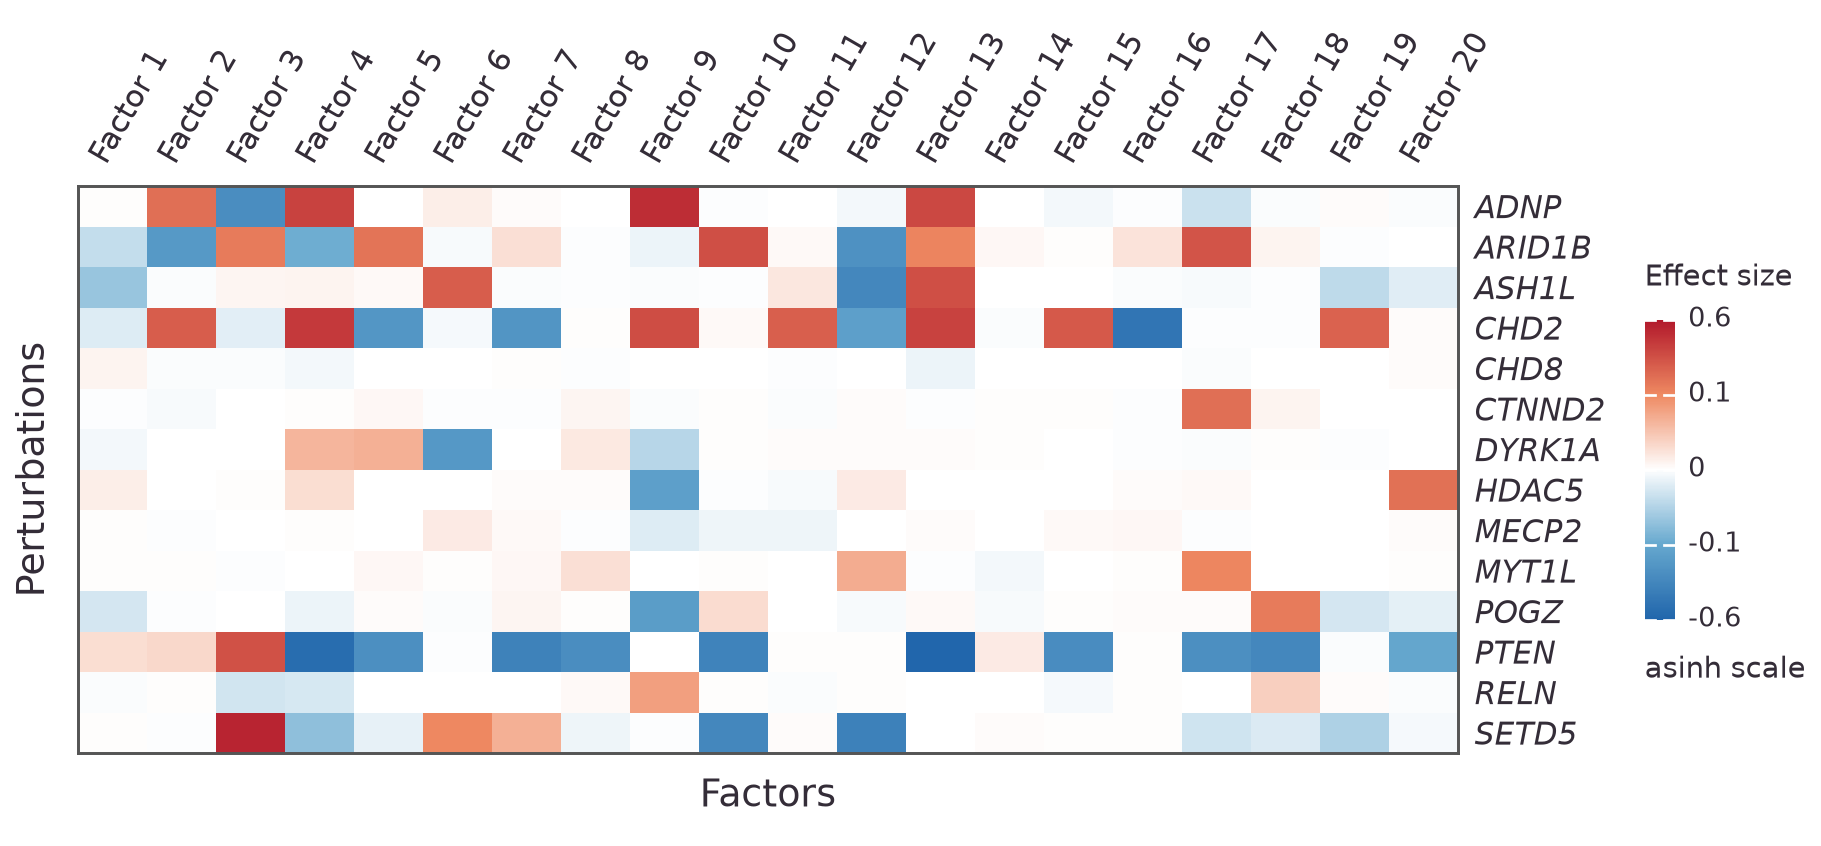

In [ ]:
B = pd.read_csv(result_dir / "B.csv", index_col=0)

fig = pp.plot_factor_effects(
    B,
    perturbations=B.index.drop("Nontargeting").tolist(),
    show_significance=False,
    scale="asinh",
)

save(fig, "01_factor_effects_full")

**With significance:** the same matrix, with dots marking coefficient PIP > 0.95.

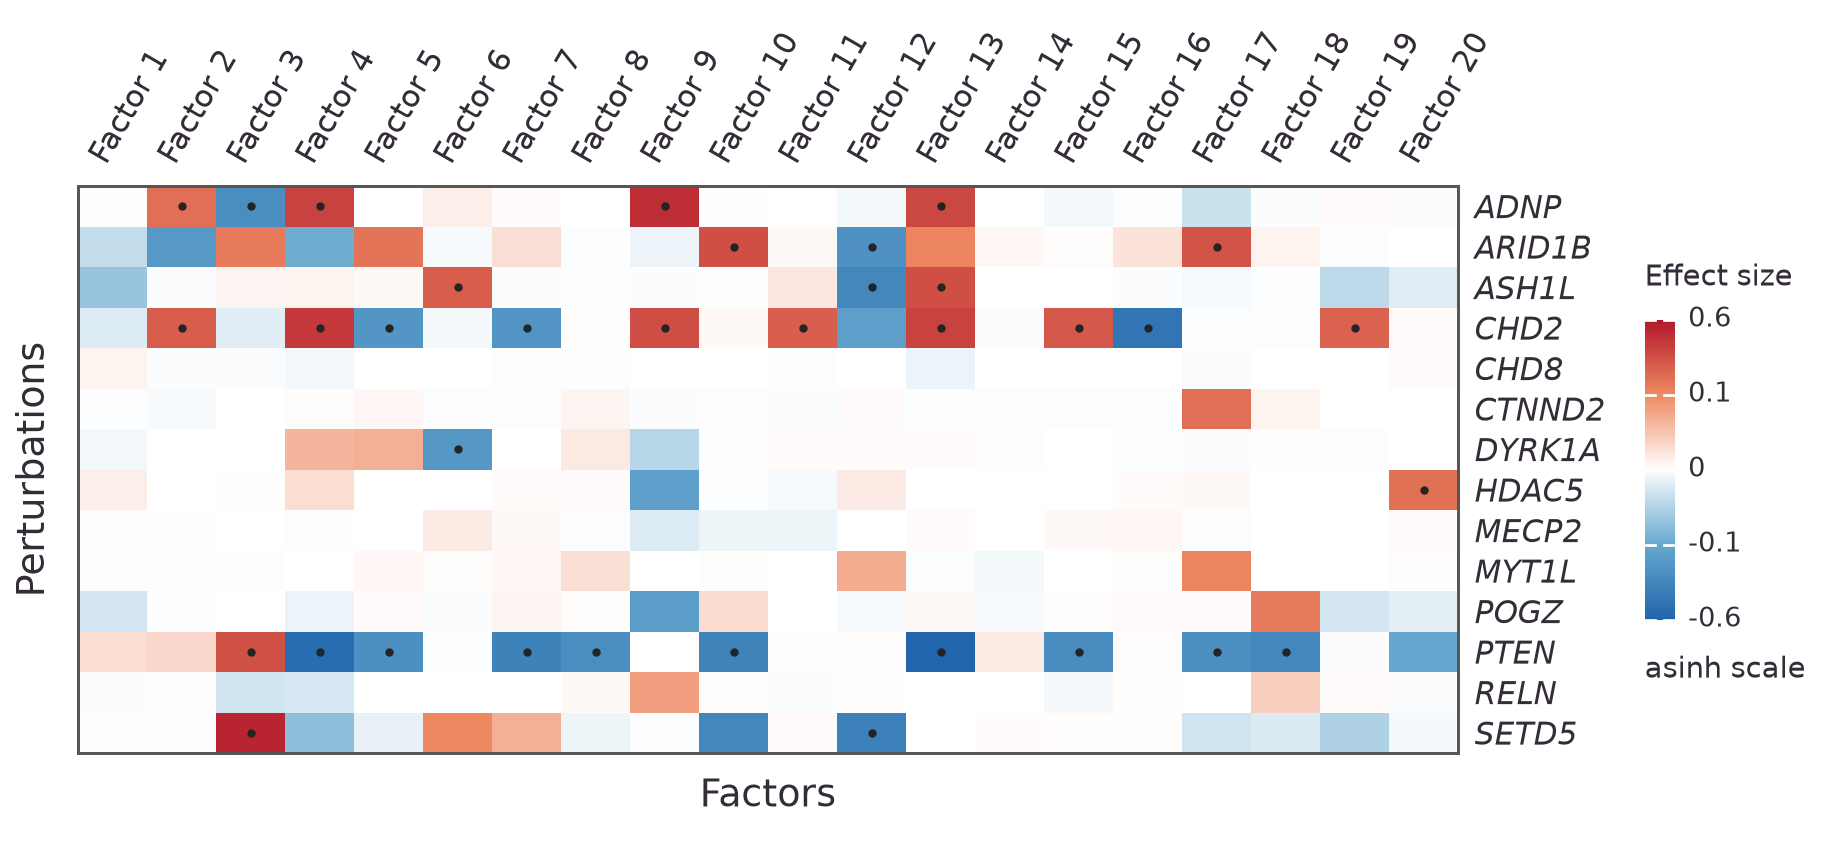

In [ ]:
PIP_B = pd.read_csv(result_dir / "PIP_B.csv", index_col=0)

fig = pp.plot_factor_effects(
    B,
    perturbations=B.index.drop("Nontargeting").tolist(),
    scale="asinh",
    pip=PIP_B,
    show_significance=True, # must be True to show significance based on pip
  )

save(fig, "01_factor_effects_with_pip")

**Subset:** six selected perturbations across eleven factors.

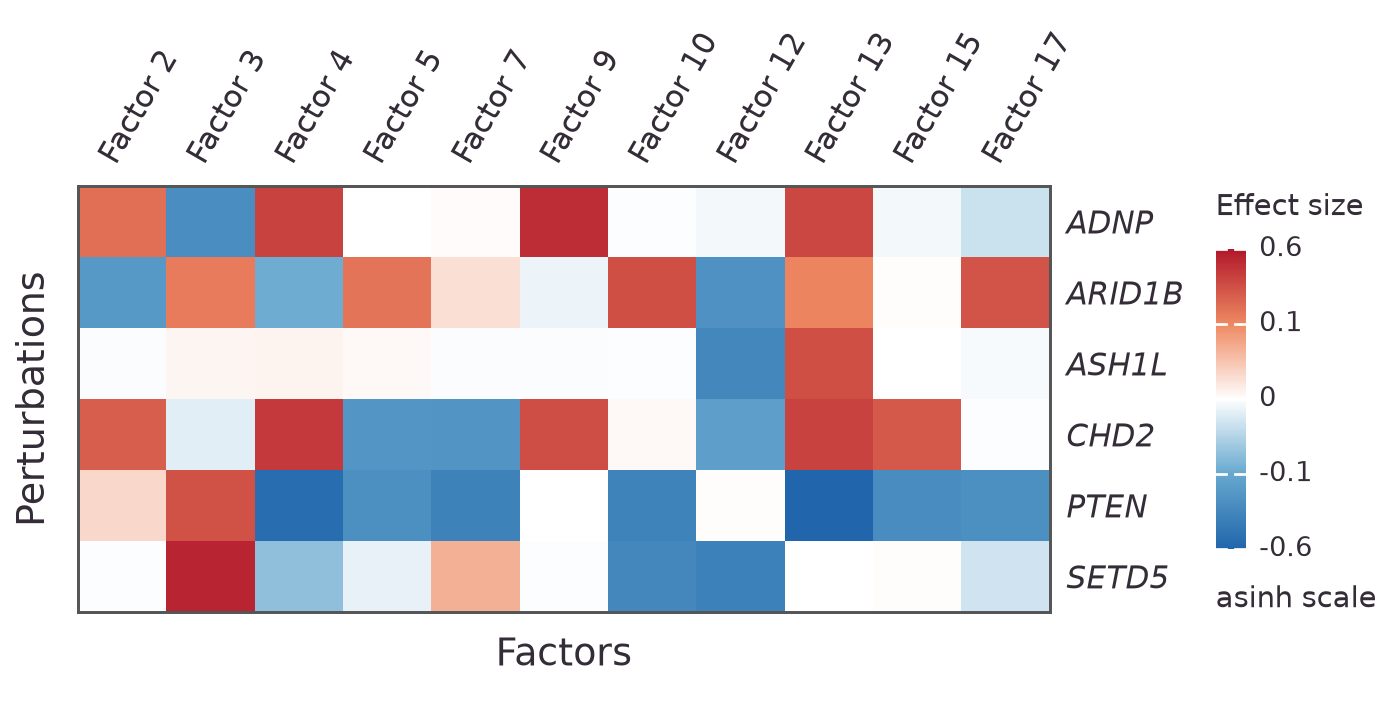

In [ ]:
fig = pp.plot_factor_effects(
    B,
    perturbations=["ADNP", "ARID1B", "ASH1L", "CHD2", "PTEN", "SETD5"],
    factors=["factor_1", "factor_2", "factor_3", "factor_4", "factor_6", "factor_8",
             "factor_9", "factor_11", "factor_12", "factor_14", "factor_16"],
    show_significance=False,
    scale="asinh",
)
save(fig, "01_factor_effects_subset")

## 7. Provide marker gene annotations

The 30 selected marker genes are a subset of the 6,000 modeled genes. `gene_annotations.csv` contains:

- `gene_ID`: fitted identifier, matching `W.csv` and `BW.csv`.
- `gene_name`: display label, typically a gene symbol.
- `annotation`: category used for grouping and the legend.

Groups follow annotation-file order. Without annotations, plots show gene IDs. Marker selection combines biological evidence and fitted effects; it does not independently establish neuronal specificity.

In [ ]:
# 30 gene annotations
annotations = pd.read_csv(result_dir / "gene_annotations.csv")
selected_30_genes = annotations["gene_ID"].tolist()

print(annotations.head(n=15))

            gene_ID gene_name                 annotation
0   ENSG00000183036      PCP4  neuron diff. / maturation
1   ENSG00000277586      NEFL  neuron diff. / maturation
2   ENSG00000143320    CRABP2  neuron diff. / maturation
3   ENSG00000131711     MAP1B  neuron diff. / maturation
4   ENSG00000162374    ELAVL4  neuron diff. / maturation
5   ENSG00000078018      MAP2  neuron diff. / maturation
6   ENSG00000166710       B2M     neg. reg. neuron diff.
7   ENSG00000179218      CALR     neg. reg. neuron diff.
8   ENSG00000138083      SIX3     neg. reg. neuron diff.
9   ENSG00000135916     ITM2C  neg. reg. projection dev.
10  ENSG00000196591     HDAC2  neg. reg. projection dev.
11  ENSG00000072832     CRMP1  neg. reg. projection dev.
12  ENSG00000108947     EFNB3  neg. reg. projection dev.
13  ENSG00000170017     ALCAM     neuron projection dev.
14  ENSG00000075624      ACTB     neuron projection dev.


## 8. Gene loadings on factors

Loadings already include inclusion weighting. Interpret them alongside perturbation effects: reversing both signs for a factor leaves its overall gene contribution unchanged.

**Full matrix:** 30 selected marker genes across all 20 factors.

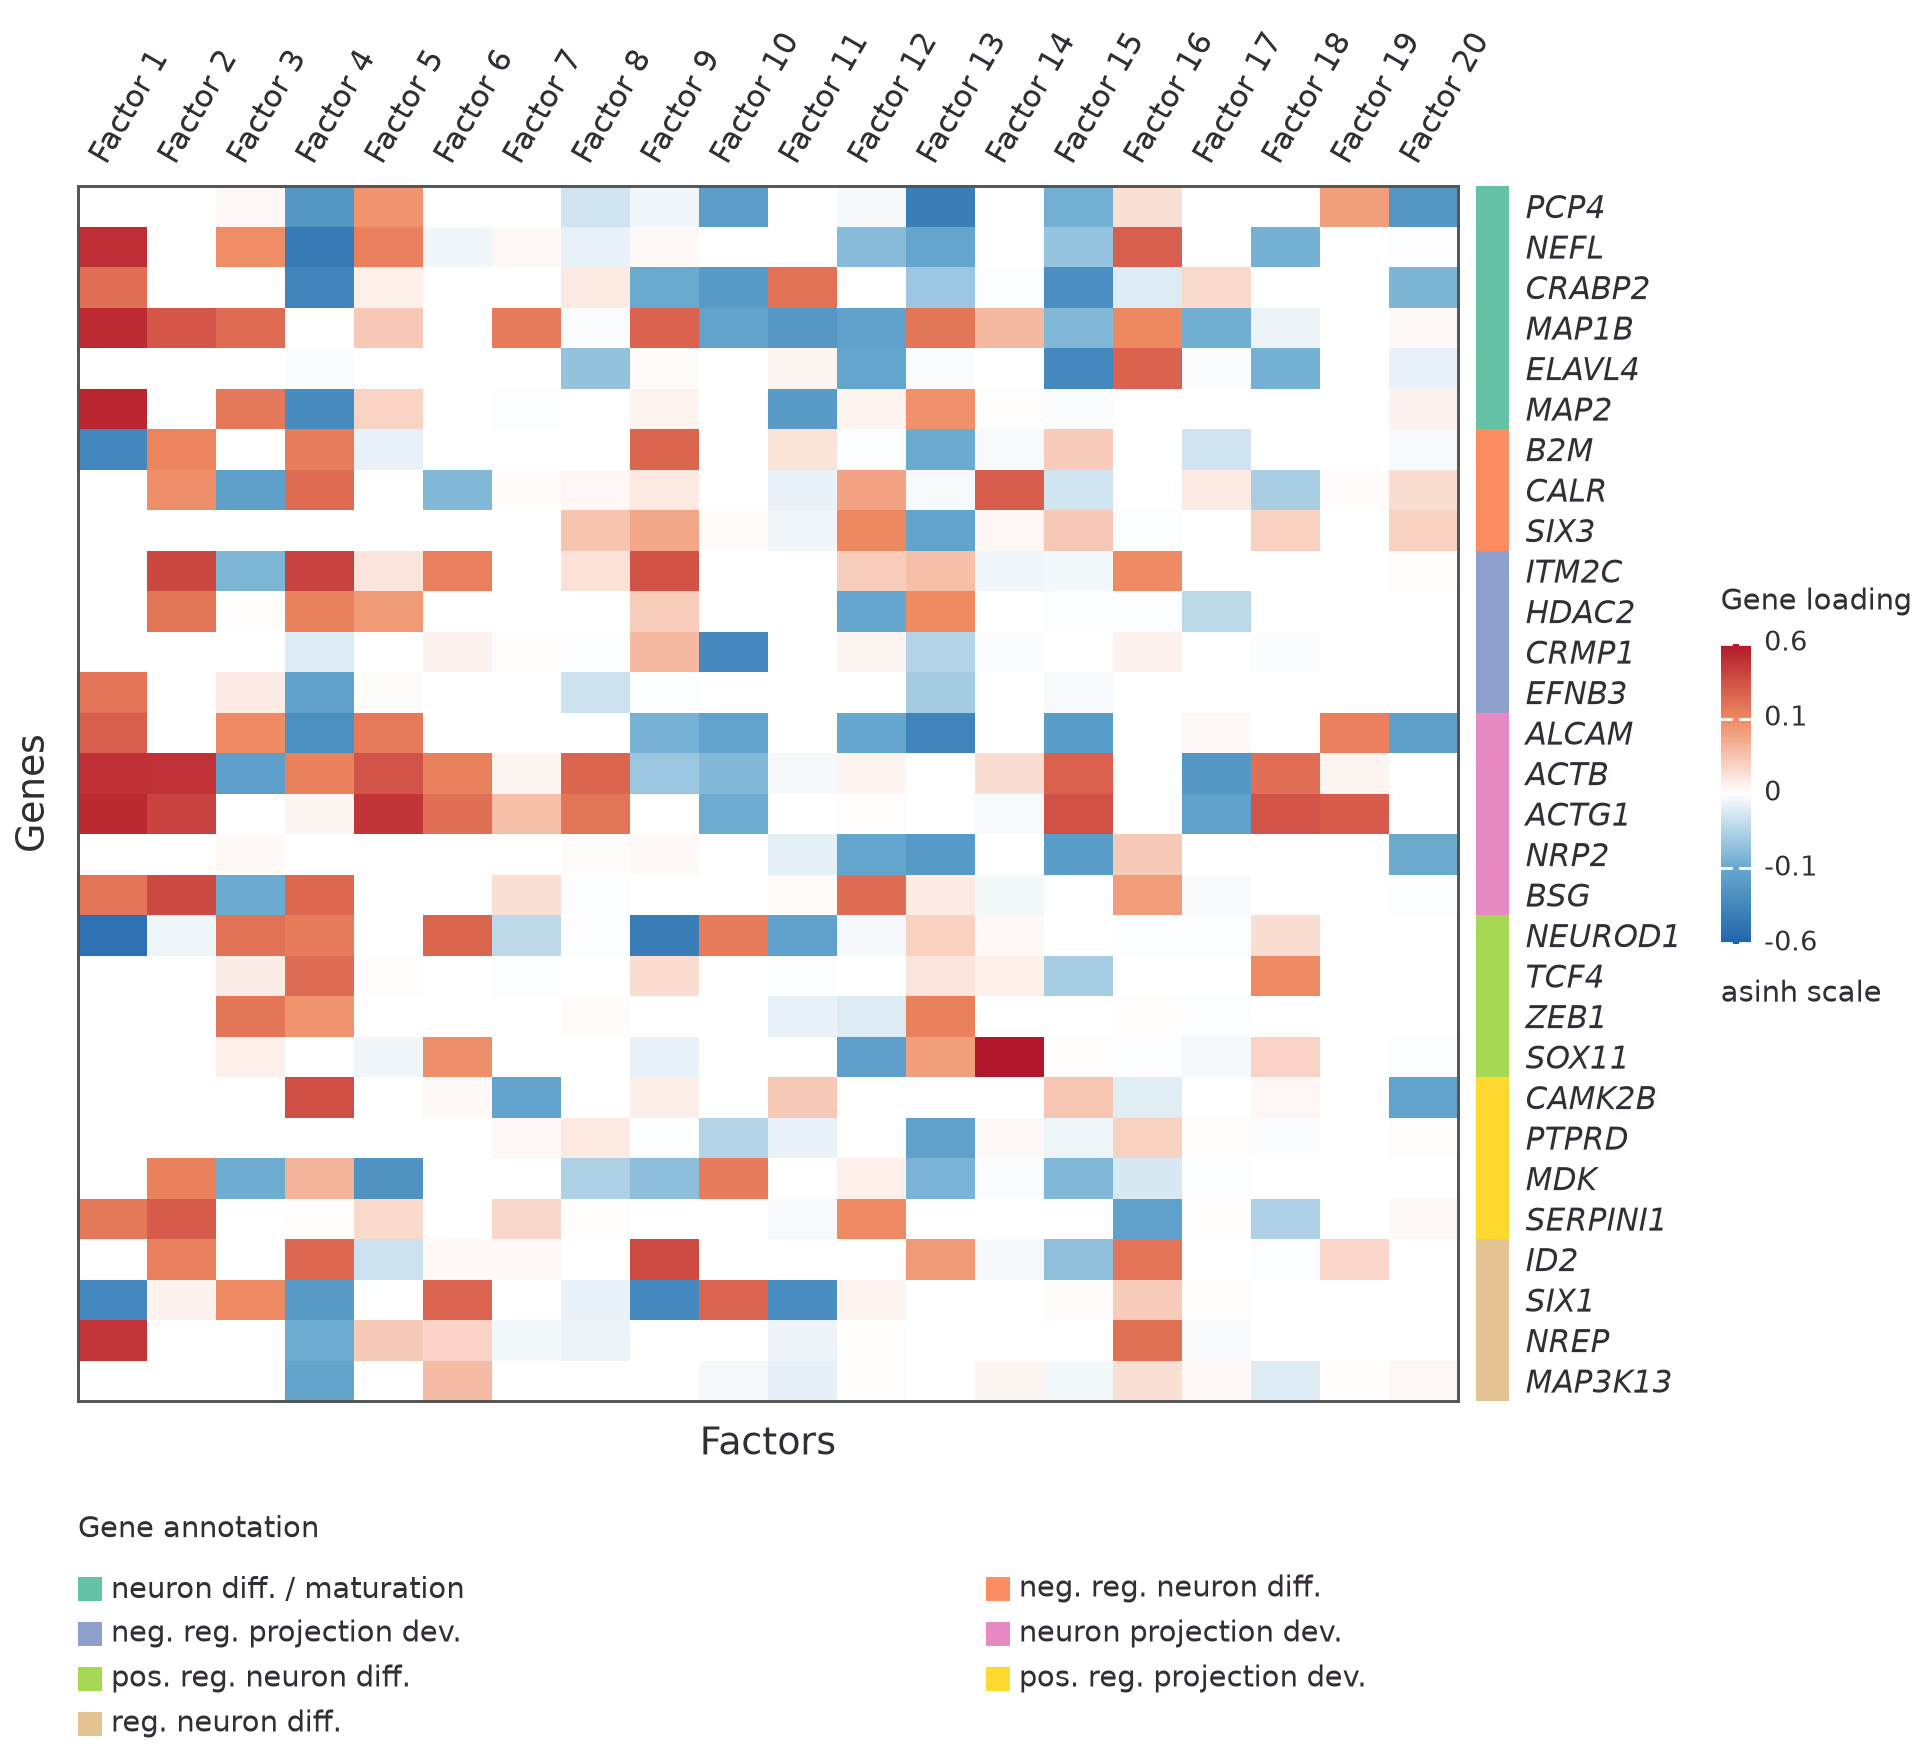

In [ ]:
W = pd.read_csv(result_dir / "W.csv", index_col=0)

fig = pp.plot_gene_loadings(
    W,
    genes=selected_30_genes,
    gene_annotations=annotations,
    show_significance=False,
    scale="asinh",
)

save(fig, "02_gene_loadings_all_factors")

**With significance:** the same matrix, with dots marking loading PIP > 0.95.

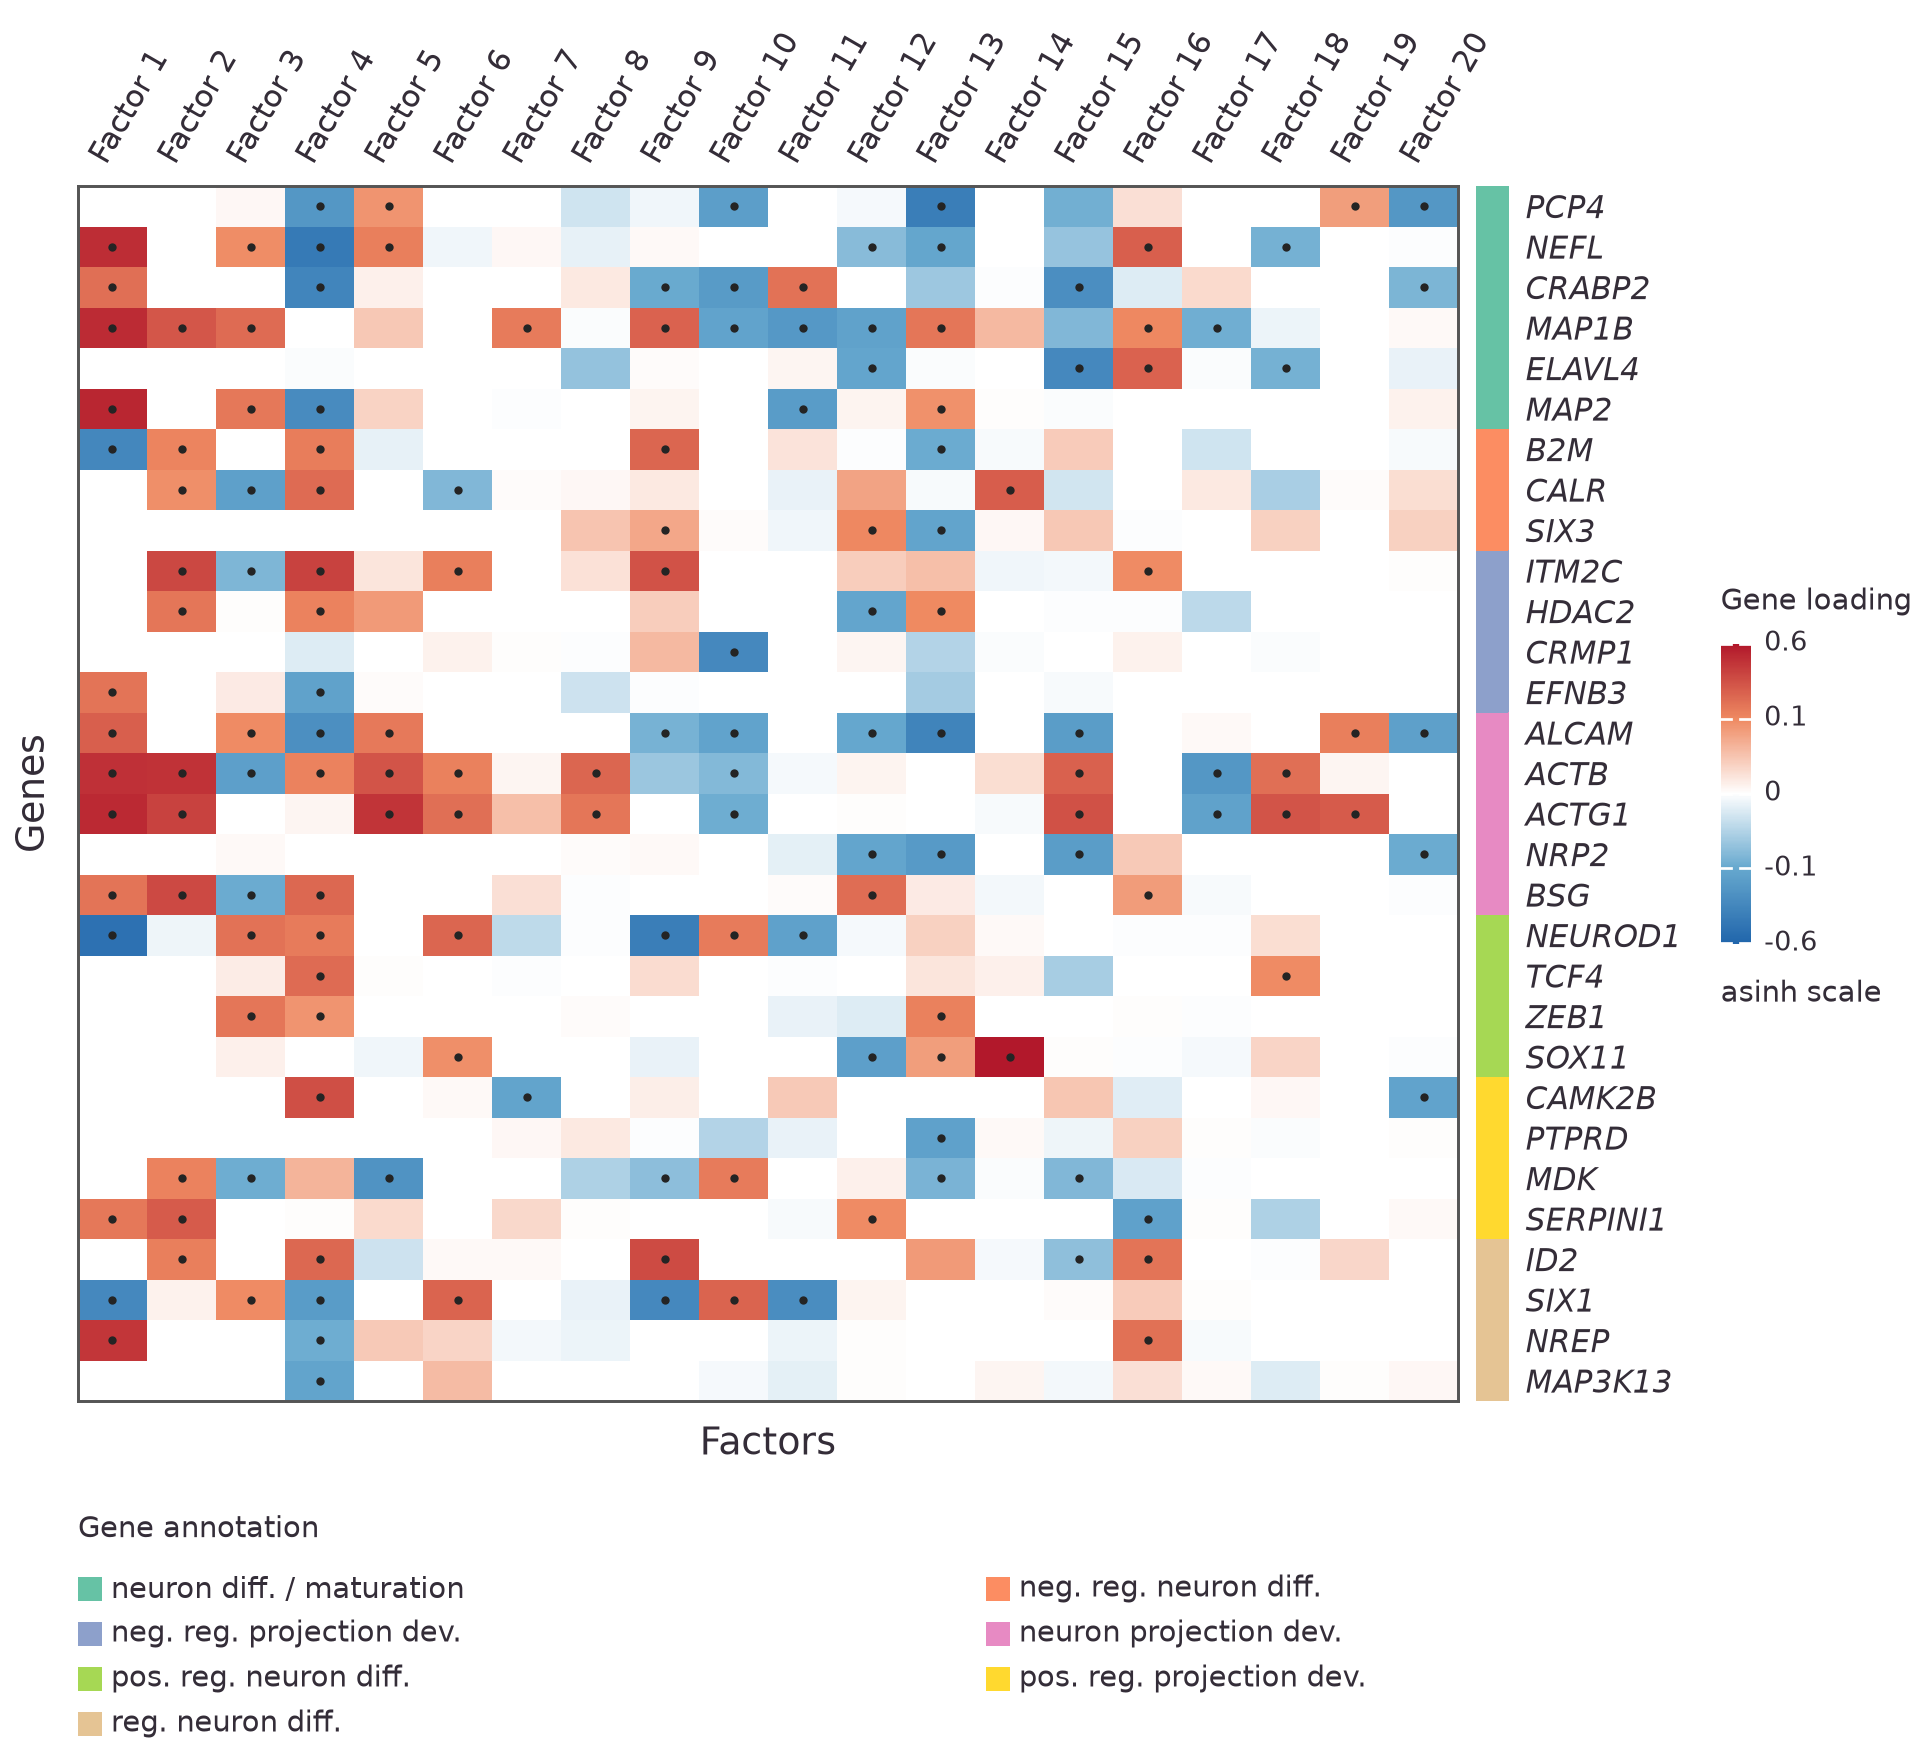

In [ ]:
PIP_W = pd.read_csv(result_dir / "PIP_W.csv", index_col=0)

fig = pp.plot_gene_loadings(
    W,
    genes=selected_30_genes,
    gene_annotations=annotations,
    pip=PIP_W,
    show_significance=True,
    scale="asinh",
)

save(fig, "02_gene_loadings_with_pip")

**Subset:** the same 30 marker genes across eleven selected factors.

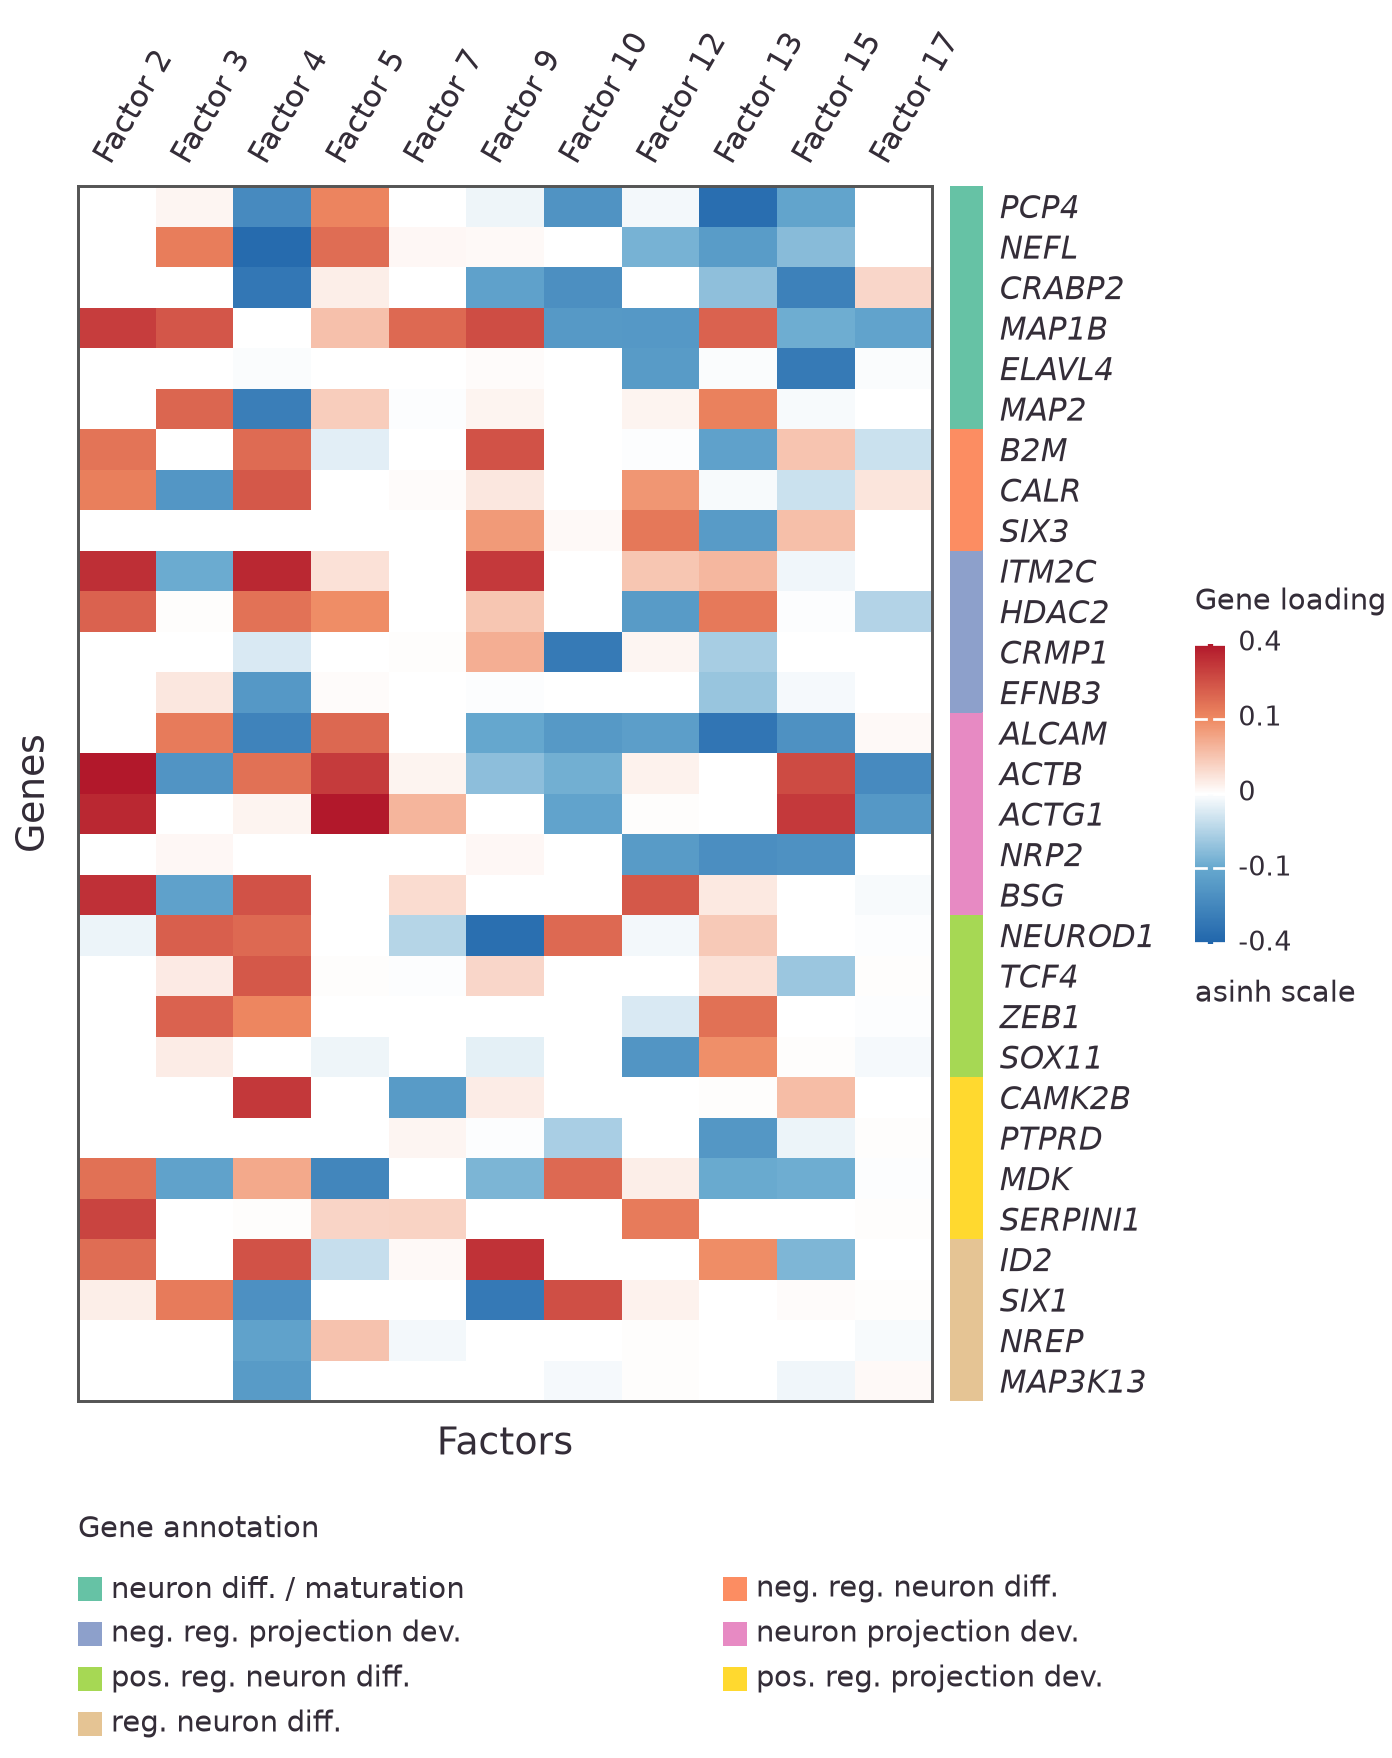

In [ ]:
fig = pp.plot_gene_loadings(
    W,
    genes=selected_30_genes,
    factors=["factor_1", "factor_2", "factor_3", "factor_4", "factor_6", "factor_8",
             "factor_9", "factor_11", "factor_12", "factor_14", "factor_16"],
    gene_annotations=annotations,
    show_significance=False,
    scale="asinh",
)
save(fig, "02_gene_loadings_subset")

## 9. Overall perturbation effects on genes

`BW = B @ W` combines all fitted factors, including those omitted from plotting subsets. Effects are on the processed expression scale, not log fold changes. Colors show effect sizes; dots indicate significance.

In [ ]:
overall = B @ W

**Full matrix:** 30 selected marker genes across all 14 perturbations.

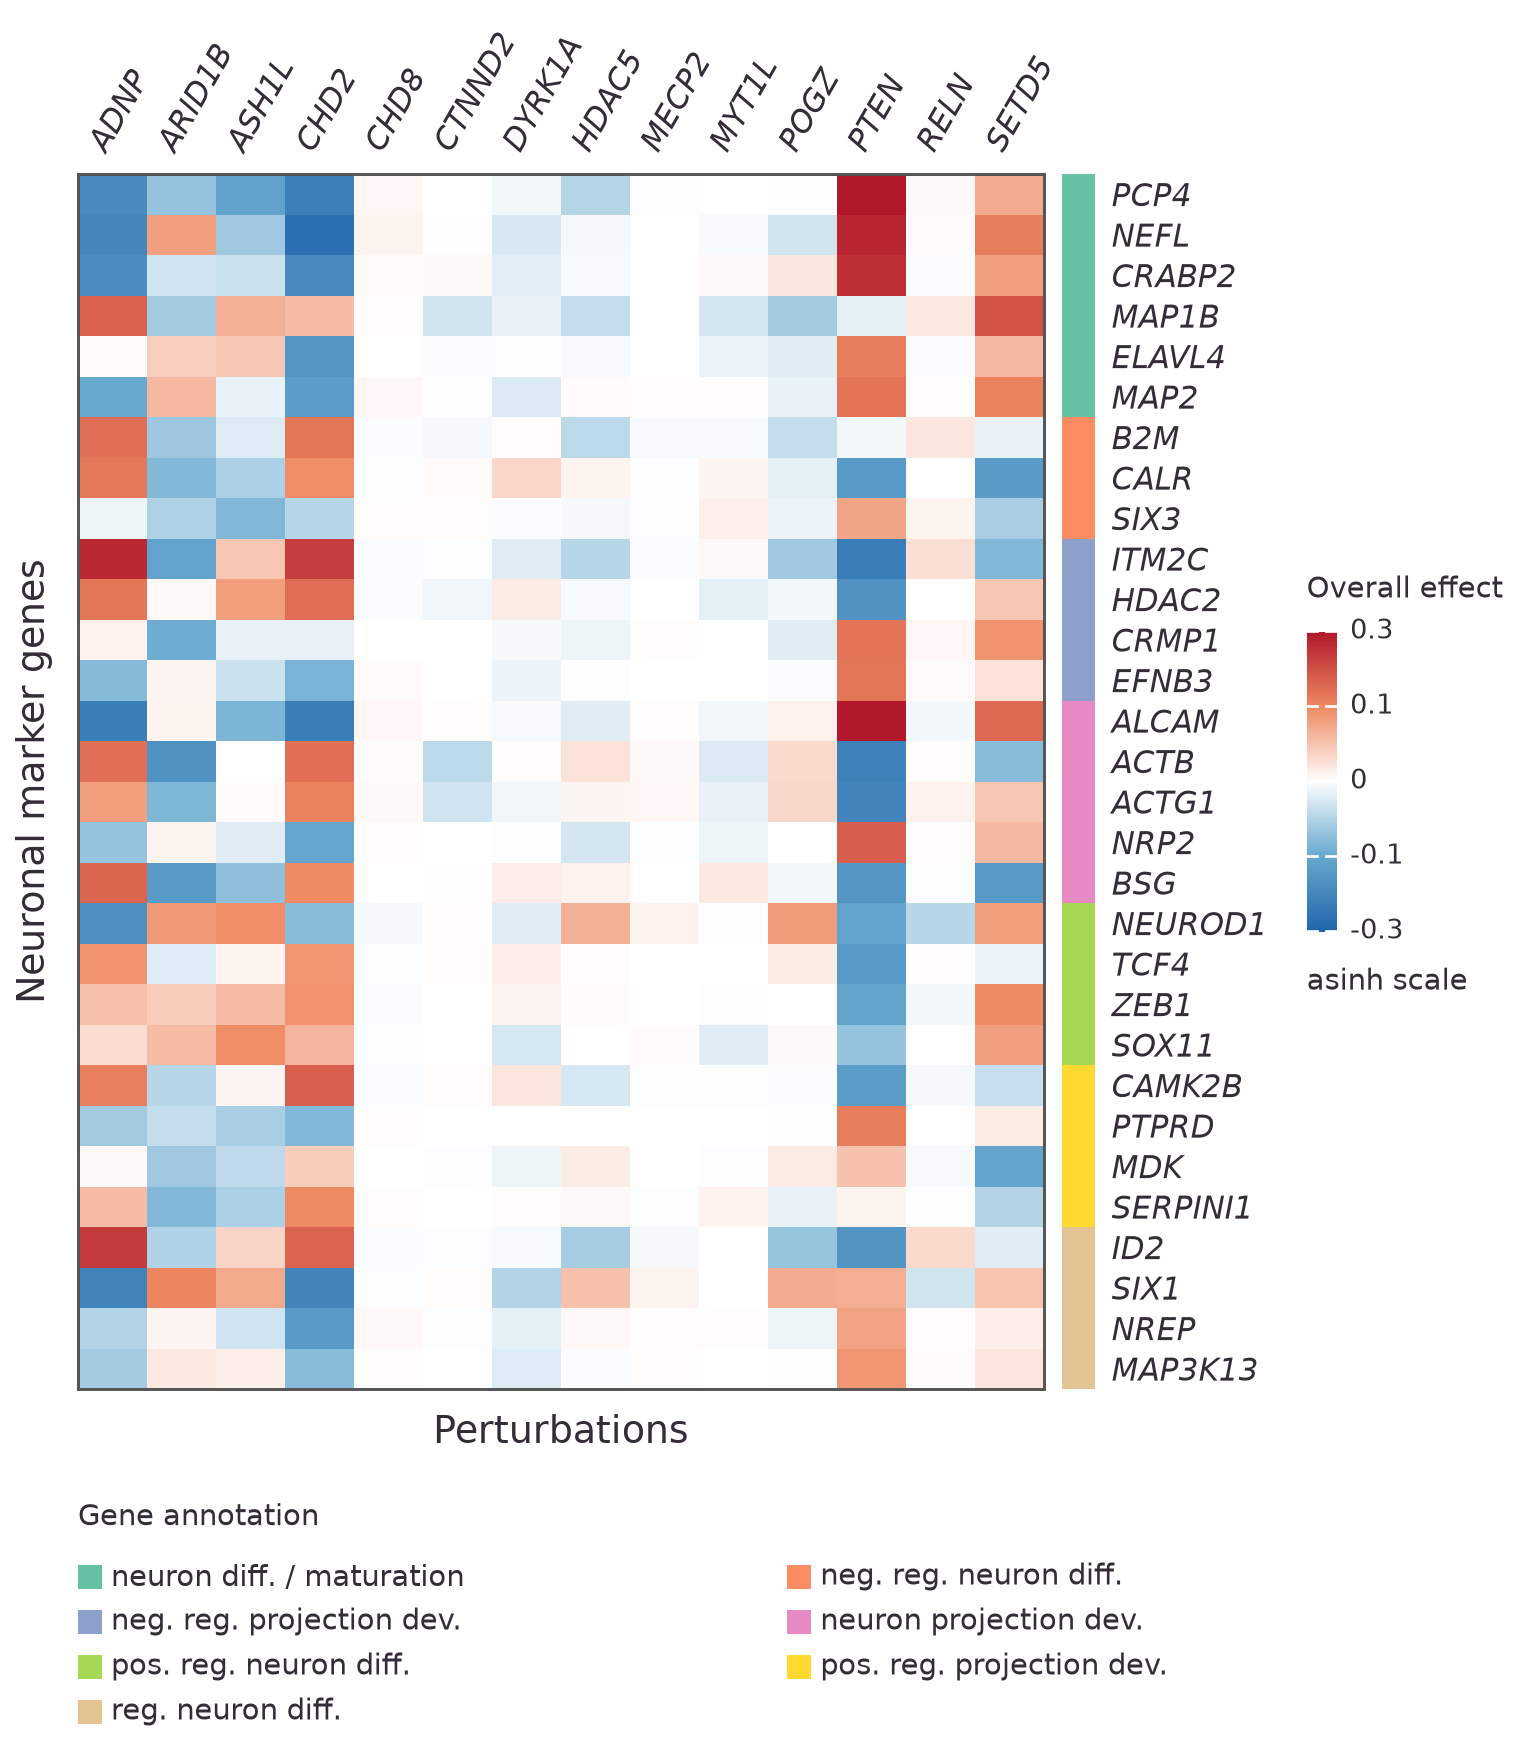

In [ ]:
BW = pd.read_csv(result_dir / "BW.csv", index_col=0)

fig = pp.plot_gene_effects(
    BW,
    genes=selected_30_genes,
    perturbations=BW.index.drop("Nontargeting").tolist(),
    gene_annotations=annotations,
    show_significance=False,
    scale="asinh",
)

fig.axes[0].set_ylabel("Neuronal marker genes")
save(fig, "03_gene_effects_all_targets")

**With significance:** the same matrix, with dots marking LFSR < 0.05.

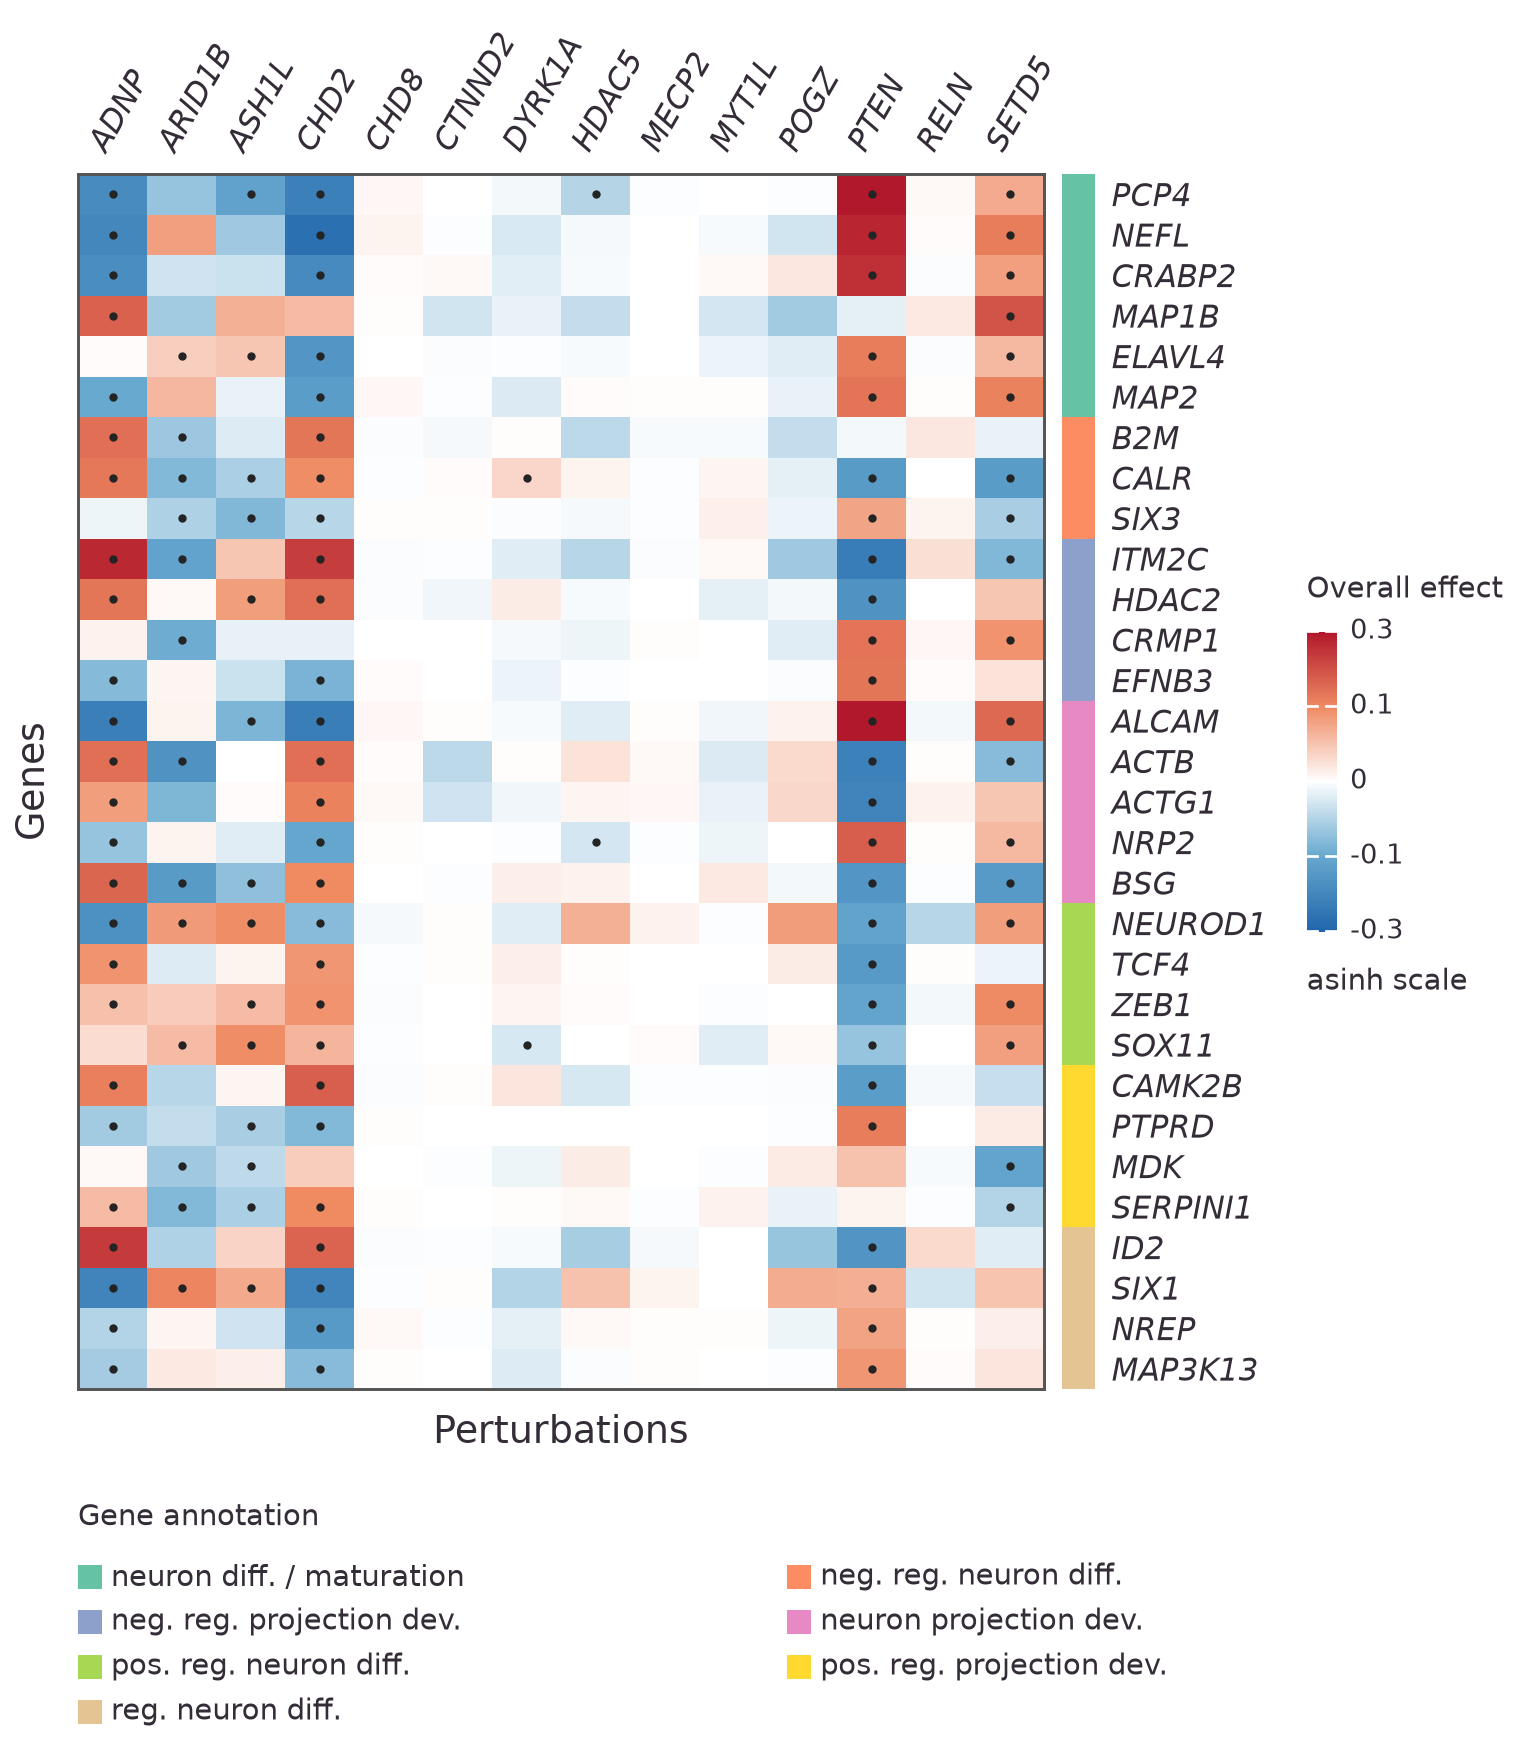

In [ ]:
LFSR_BW = pd.read_csv(result_dir / "LFSR_BW.csv", index_col=0)

fig = pp.plot_gene_effects(
    BW,
    genes=selected_30_genes,
    perturbations=BW.index.drop("Nontargeting").tolist(),
    gene_annotations=annotations,
    scale="asinh",
    lfsr=LFSR_BW,
    show_significance=True, # must be True to show significance based on lfsr
)

save(fig, "03_gene_effects_all_targets_with_lfsr")

**Subset:** the same 30 marker genes across six selected perturbations.

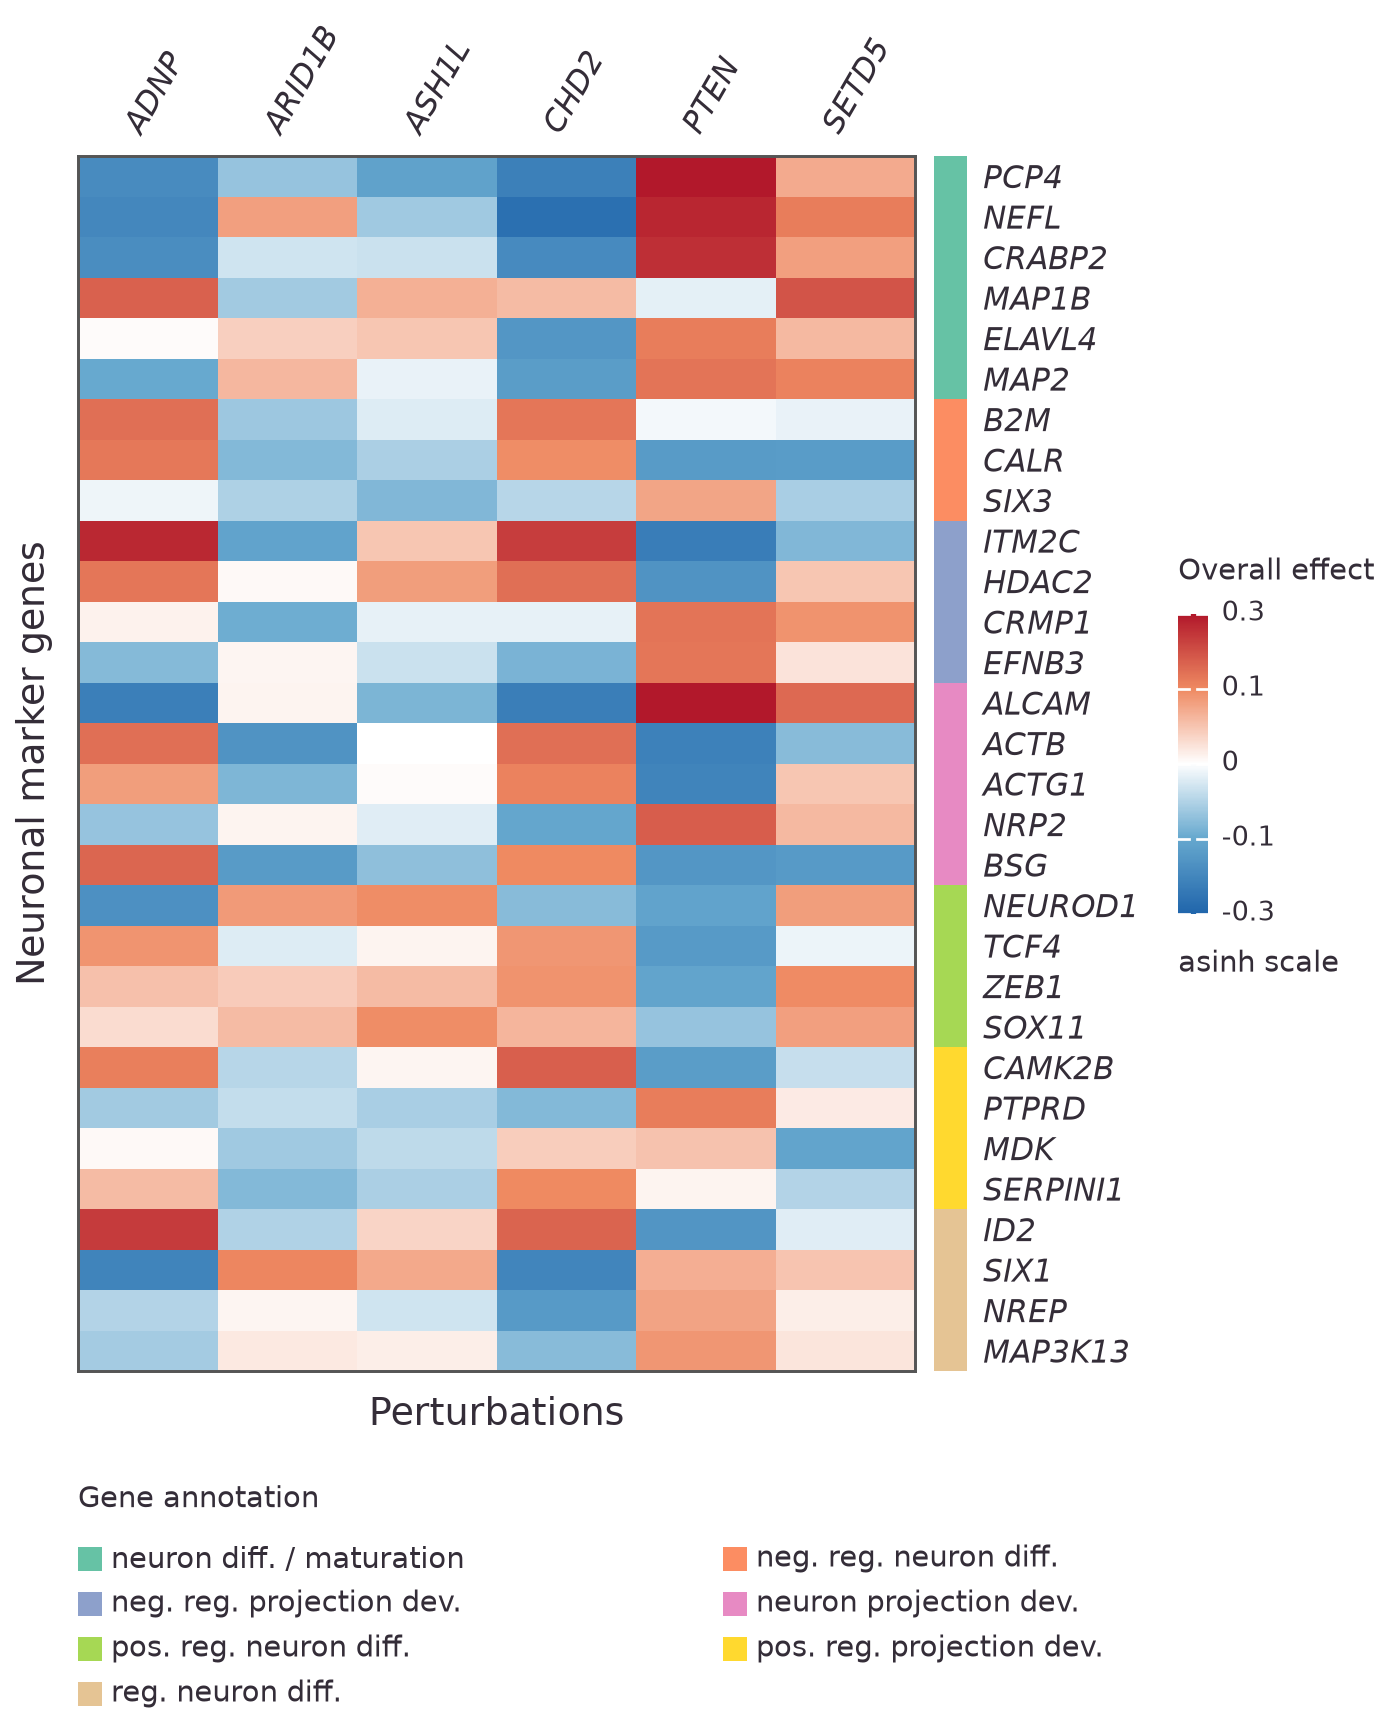

In [ ]:
fig = pp.plot_gene_effects(
    BW,
    genes=selected_30_genes,
    perturbations=["ADNP", "ARID1B", "ASH1L", "CHD2", "PTEN", "SETD5"],
    gene_annotations=annotations,
    show_significance=False,
    scale="asinh",
)

fig.axes[0].set_ylabel("Neuronal marker genes")
save(fig, "03_gene_effects_subset")

## 10. DEGs per factor

Count genes with loading PIP > 0.95 for each factor. These are factor-associated genes; perturbation DEGs below use LFSR < 0.05. A gene may be counted for multiple factors.

In [ ]:
PIP_W = pd.read_csv(result_dir / "PIP_W.csv", index_col=0)
factor_degs = (PIP_W > 0.95).sum(axis=1)
factor_labels = [str(int(factor.removeprefix("factor_")) + 1)
                 for factor in factor_degs.index]

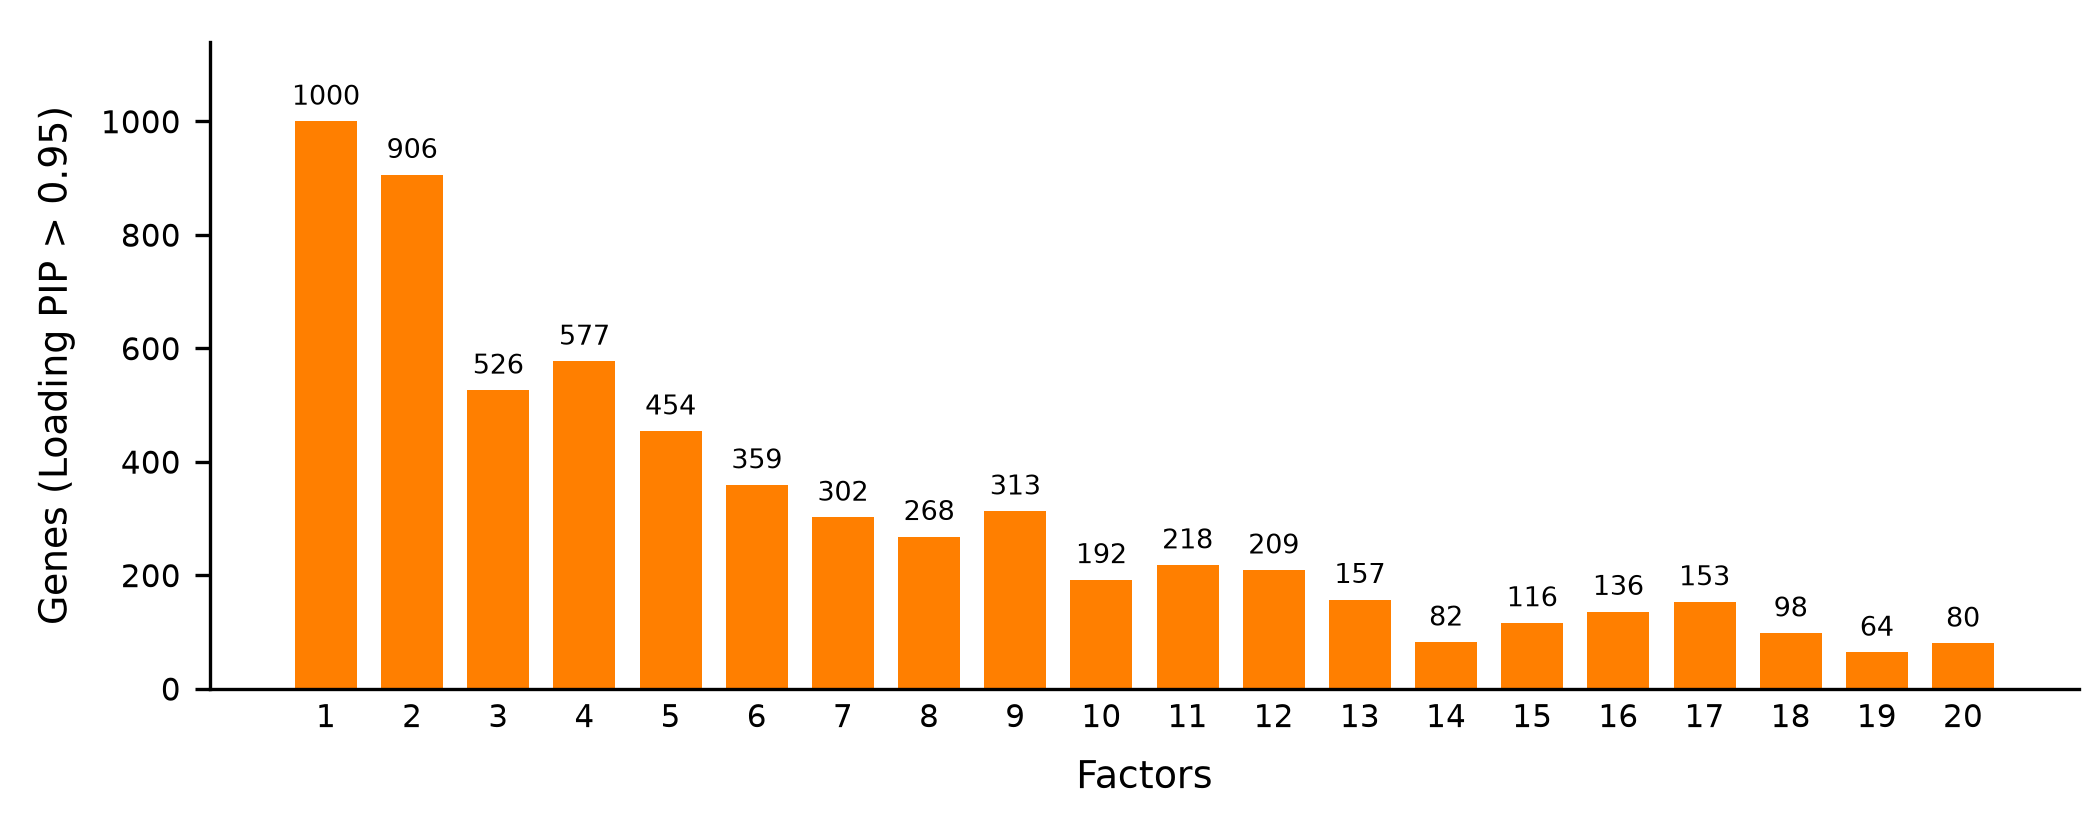

In [ ]:
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.bar(factor_labels, factor_degs.values, color="#FF7F00", width=0.72)
ax.set(xlabel="Factors", ylabel="Genes (Loading PIP > 0.95)")
peak = max(factor_degs.max(), 1)
ax.set_ylim(0, 1.14 * peak)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", length=0, labelsize=7.5)
ax.tick_params(axis="y", labelsize=7.5)
ax.xaxis.label.set_fontsize(9)
ax.yaxis.label.set_fontsize(9)
ax.xaxis.labelpad = ax.yaxis.labelpad = 6
for i, value in enumerate(factor_degs):
    ax.text(i, value + 0.018 * peak, str(value),
            ha="center", va="bottom", fontsize=6.5)
fig.subplots_adjust(left=0.10, right=0.99, bottom=0.18, top=0.95)
save(fig, "04_degs_per_factor")

## 11. DEGs per perturbation

Count genes with LFSR < 0.05 for each of the 14 perturbations, excluding the `Nontargeting` control. Summing the bars counts gene-perturbation pairs, since a gene can be significant under multiple perturbations.

In [ ]:
LFSR_BW = pd.read_csv(result_dir / "LFSR_BW.csv", index_col=0)
degs = (LFSR_BW < 0.05).sum(axis=1)

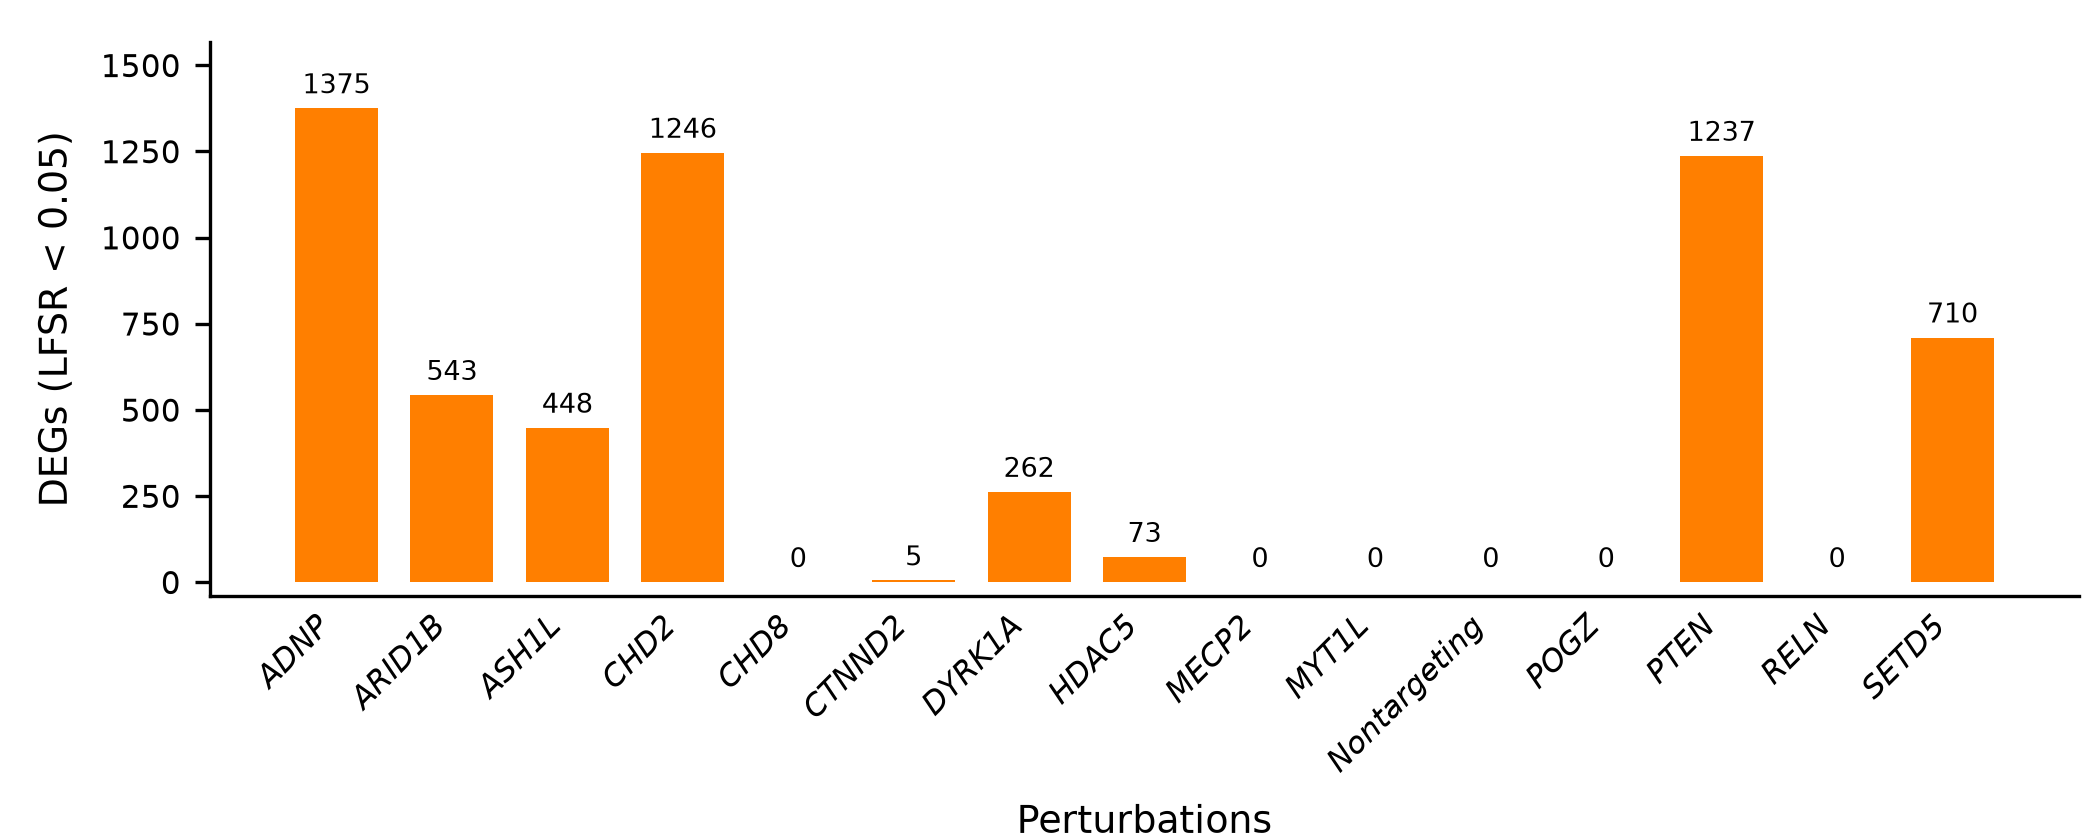

In [ ]:
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.bar(degs.index, degs.values, color="#FF7F00", width=0.72)
ax.set(xlabel="Perturbations", ylabel="DEGs (LFSR < 0.05)")
ax.set_ylim(-0.03 * max(degs), 1.14 * max(degs))
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", rotation=45, length=0, labelsize=7.5)
ax.tick_params(axis="y", labelsize=7.5)
for tick in ax.get_xticklabels():
    tick.set(ha="right", fontstyle="italic")
ax.xaxis.label.set_fontsize(9)
ax.yaxis.label.set_fontsize(9)
ax.xaxis.labelpad = ax.yaxis.labelpad = 6
for i, value in enumerate(degs):
    ax.text(i, value + 0.018 * max(degs), str(value),
            ha="center", va="bottom", fontsize=6.5)
fig.subplots_adjust(left=0.10, right=0.99, bottom=0.29, top=0.95)
save(fig, "05_degs_per_perturbation")

## 12. GO enrichment and neuronal terms

Run [run_enrichment_factor.R](https://github.com/mancusolab/perturbvi_analysis/blob/main/luhmes/run_enrichment_factor.R):

```bash
Rscript run_enrichment_factor.R
```

For each factor, the script selects genes with loading PIP > 0.95 and tests GO Biological Process enrichment against all 6,000 modeled genes. Both loading signs are included; BH FDR < 0.05 is applied separately per factor.

```r
WebGestaltR::WebGestaltR(
  enrichMethod = "ORA",
  organism = "hsapiens",
  enrichDatabase = "geneontology_Biological_Process_noRedundant",
  interestGene = foreground,
  interestGeneType = "ensembl_gene_id",
  referenceGene = background,
  referenceGeneType = "ensembl_gene_id",
  minNum = 10,
  maxNum = 500,
  fdrMethod = "BH",
  sigMethod = "fdr",
  fdrThr = 0.05,
  isOutput = FALSE
)
```

The script writes `luhmes_out/enrichment/factor_go.csv` and the figure below. Internet access is required; database updates may change results.

The saved analysis has 282 significant associations across 148 terms and 18 factors. Filtering neuronal terms after correction gives the **20 associations, 11 terms, and eight factors** shown here.

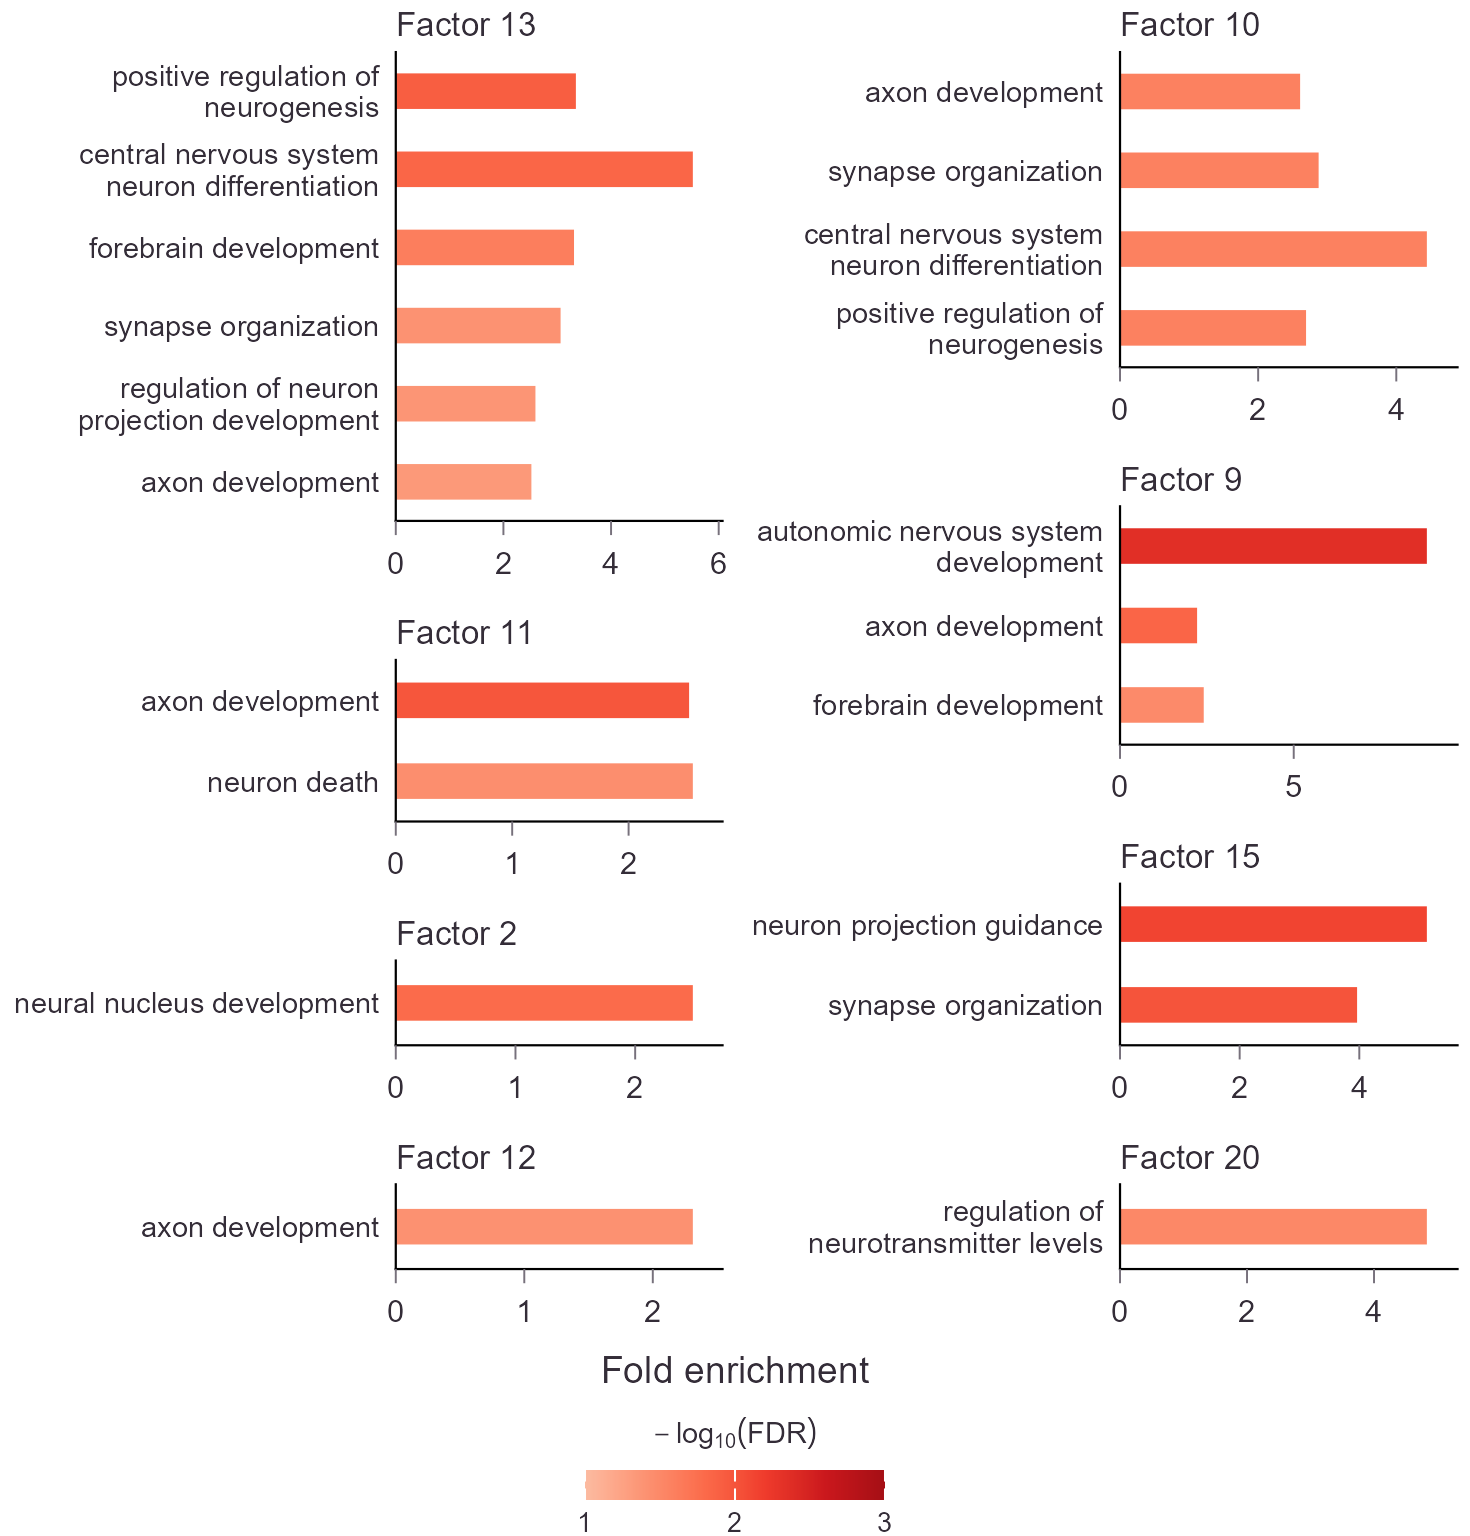

Bar length shows fold enrichment; each factor has its own x-axis range. Darker red means lower FDR. The color scale ends at FDR = 0.001 (-log10(FDR) = 3), so all smaller FDRs share the darkest red. This keeps very small FDRs from stretching the color scale; significance is still determined by FDR < 0.05.
